# Broadway Network Analysis

## Objectives

This notebook aims to move away from the performer-show network in 01 and 02 and creating a performer-performer network.

In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations

df = pd.read_csv("../data/raw/broadway_cast.csv")

show_groups = df.groupby("show")["person"].apply(list)

show_groups

In [2]:
G = nx.Graph()

for show, people in show_groups.items():

    for person1, person2 in combinations(people, 2):
        G.add_edge(
            person1,
            person2,
            show=show
        )

print(G.number_of_nodes())
print(G.number_of_edges())

11
11


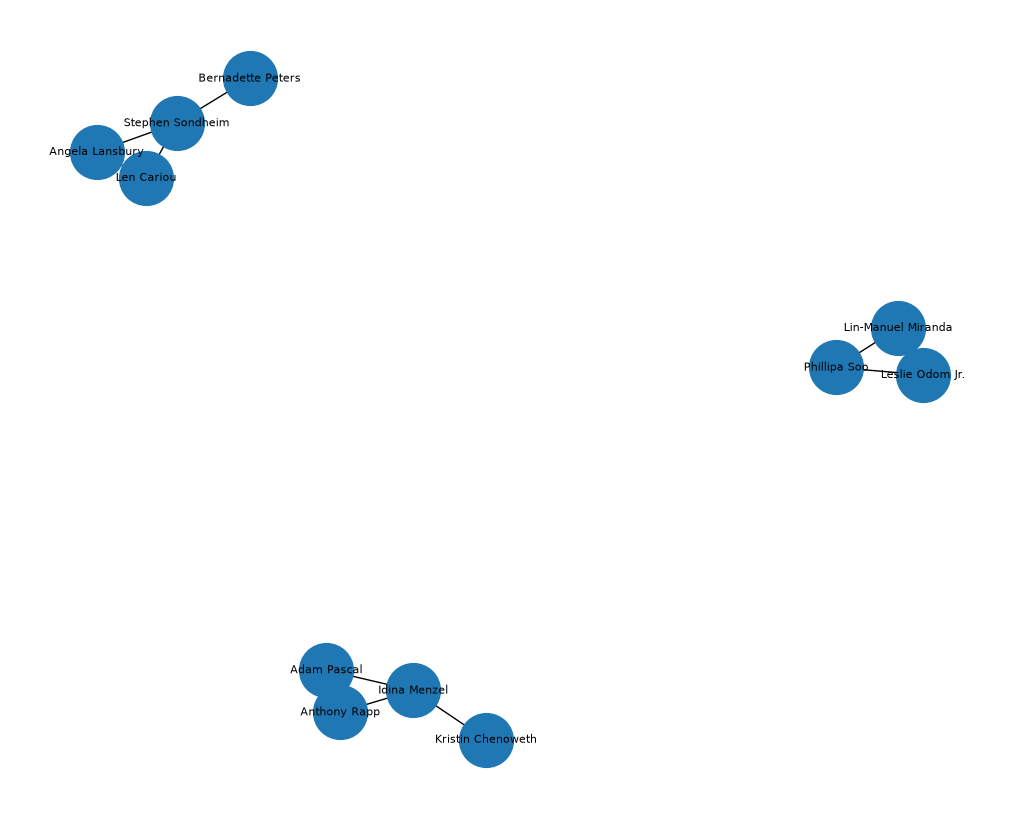

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=8
)

plt.show()